In [ ]:
import sys
sys.path.append('/home/salzmann/Desktop/einc/cluster_home/ultracold-dipolar/Own_program_vault')
import main_version_2 as mv2
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib import colors
import os
import gc

fontsize = 15
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['legend.handlelength'] = 0.5


pgf_with_rc_fonts = {
    "font.family": "serif",
    "font.serif": [],
    "font.sans-serif": ["DejaVu Sans"]
}
plt.rcParams.update(pgf_with_rc_fonts)

plt.rc('font', **{'family': 'serif', 'serif': ['Computer Modern Roman'],
                  'size': fontsize})
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath} \usepackage{amsfonts}')
plt.rc('legend', fontsize=fontsize,
       title_fontsize=fontsize)


# Get the current working directory (where the notebook is running)
current_directory = os.getcwd()


In [ ]:
import re
ground_state_files = []

# Updated regex to match "ground_state_wave_function_0.vtk"
name_pattern = re.compile(r"slice_(\d+)\.vtk$")

for root, dirs, files in os.walk(current_directory, topdown=True):
    for filename in files:
        if name_pattern.match(filename):
            full_path = os.path.join(root, filename)
            ground_state_files.append(full_path)




In [ ]:
import os

def numeric_sort_key(path):
    # extract N, cutoff, edd, slice (use sensible defaults if missing)
    n_m = re.search(r"N_(\d+)", path)
    cutoff_m = re.search(r"cutoff_([0-9]+)", path)
    edd_m = re.search(r"edd_([0-9.]+)", path)
    slice_m = re.search(r"slice_(\d+)\.vtk$", path)

    n_val = int(n_m.group(1)) if n_m else -1
    cutoff_val = int(cutoff_m.group(1)) if cutoff_m else -1
    edd_val = float(edd_m.group(1)) if edd_m else float('nan')
    slice_idx = int(slice_m.group(1)) if slice_m else -1

    # return tuple of numeric keys in the order you want to sort by
    # e.g. sort by N, then cutoff, then edd, then slice index, then filename as tiebreaker
    return (n_val, cutoff_val, edd_val, slice_idx, os.path.basename(path))

# usage: sorts by numeric N (so 300000 before 1000000)
ground_state_files_sorted = sorted(ground_state_files, key=numeric_sort_key)

['/home/salzmann/Desktop/einc/cluster_home/ultracold-dipolar/Static_groundstate_3/cylinder_hard_wall/N_100000_cutoff_0/r_10.185_edd_1.320/ground_state_wave_function.vtk',
 '/home/salzmann/Desktop/einc/cluster_home/ultracold-dipolar/Static_groundstate_3/cylinder_hard_wall/N_100000_cutoff_0/r_10.185_edd_1.404/ground_state_wave_function.vtk',
 '/home/salzmann/Desktop/einc/cluster_home/ultracold-dipolar/Static_groundstate_3/cylinder_hard_wall/N_100000_cutoff_0/r_10.185_edd_1.425/ground_state_wave_function.vtk',
 '/home/salzmann/Desktop/einc/cluster_home/ultracold-dipolar/Static_groundstate_3/cylinder_hard_wall/N_100000_cutoff_0/r_10.185_edd_1.467/ground_state_wave_function.vtk']

In [ ]:
realspace_densities_list = []
realpsi_list = []
imagpsi_list = []
grid_list = []
iter_list = []
write_output_every_list = []
time_step_list = []
edd_list = []
number_of_particles_list = []
cutoff_list = []
traptype_list = []
#for i in range(5, len(ground_state_files)):


for i in range(len(ground_state_files)):
    print(i, ground_state_files_sorted[i])

    j=i
    proc = mv2.TestProcessing.Three_D(file=ground_state_files_sorted[i], iteration=j)
    realspace_densities_list.append(proc.density_real_space())
    realpsi_list.append(proc.data[0])
    imagpsi_list.append(proc.data[1])
    grid_list.append(proc.r)
    iter_list.append(proc.iter)
    write_output_every_list.append(proc.write_output_every)
    time_step_list.append(proc.time_step)
    edd_list.append(proc.edd)
    number_of_particles_list.append(proc.number_of_particles)
    cutoff_list.append(proc.use_cutoff)

    TRAP = proc.trap_type

    if TRAP == "cylinder_hard_wall":
        traptype_list.append("cylindrical box trap")
    elif TRAP == "x2":
        traptype_list.append("harmonic trap")
    elif TRAP == "x4":
        traptype_list.append(r"softened trap $\propto r^4$")
    elif TRAP == "x6":
        traptype_list.append(r"softened trap $\propto r^6$")
    elif TRAP == "x8":
        traptype_list.append(r"softened trap $\propto r^8$")
    elif TRAP == "x10":
        traptype_list.append(r"softened trap $\propto r^{10}$")
    else:
        traptype_list.append(proc.trap_type)






0 /home/salzmann/Desktop/einc/cluster_home/ultracold-dipolar/Static_groundstate_3/cylinder_hard_wall/N_100000_cutoff_0/r_10.185_edd_1.320/ground_state_wave_function.vtk
1 /home/salzmann/Desktop/einc/cluster_home/ultracold-dipolar/Static_groundstate_3/cylinder_hard_wall/N_100000_cutoff_0/r_10.185_edd_1.404/ground_state_wave_function.vtk
2 /home/salzmann/Desktop/einc/cluster_home/ultracold-dipolar/Static_groundstate_3/cylinder_hard_wall/N_100000_cutoff_0/r_10.185_edd_1.425/ground_state_wave_function.vtk
3 /home/salzmann/Desktop/einc/cluster_home/ultracold-dipolar/Static_groundstate_3/cylinder_hard_wall/N_100000_cutoff_0/r_10.185_edd_1.467/ground_state_wave_function.vtk


In [8]:
def plot_in_a_row(radius, vmax_input= None, save = False, plot_phase = True):
     N = len(realspace_densities_list)  # list of 2D arrays to mimic your left plot

     if cutoff_list[0]:
          cutoff_text = "with cutoff"
     else:
          cutoff_text = "without cutoff"
           

     if plot_phase:
          fig, axes = plt.subplots(2, N, figsize=(10*N/3, 8), constrained_layout=True)

          fig.suptitle(rf"Realspace density in a {traptype_list[0]} {cutoff_text}",
                       fontsize=fontsize+3, ha='center', va='top', y=1.05)

          for i in range(len(realspace_densities_list)):

               spacing = grid_list[i][0][1] - grid_list[i][0][0]
               realspace_density = np.sum(realspace_densities_list[i]*spacing, axis=2)
               psi_real = np.sum(realpsi_list[i]*spacing, axis=2)
               psi_imag = np.sum(imagpsi_list[i]*spacing, axis=2)


               tn = iter_list[i]*write_output_every_list[i]*time_step_list[i]
               edd = edd_list[i]
               r = grid_list[i]



               X_axis, Y_axis, Z_axis = r
               X_idx = np.where(np.abs(X_axis) < radius * 1.2)[0]
               Y_idx = np.where(np.abs(Y_axis) < radius * 1.2)[0]
               
               X_slice = slice(X_idx.min(), X_idx.max() + 1)
               Y_slice = slice(Y_idx.min(), Y_idx.max() + 1)
               Plot_slice = np.s_[X_slice, Y_slice]

               psi_real = psi_real[Plot_slice]
               psi_imag = psi_imag[Plot_slice]
               realspace_density = realspace_density[Plot_slice]



               x_ticks_values = [-radius, 0, radius]
               y_ticks_values = [-radius, 0, radius]
               x_ticks_indices = [np.abs(X_axis[X_idx] - value).argmin() for value in x_ticks_values]
               y_ticks_indices = [np.abs(Y_axis[Y_idx] - value).argmin() for value in y_ticks_values]




               density_cmap = plt.get_cmap('viridis')
               phase_cmap = plt.get_cmap('twilight')


               if vmax_input is None:
                         vmax = np.max(realspace_density)
               else:
                    vmax = vmax_input

               exponent = int(np.floor(np.log10(vmax)))
               N_exponent = int(np.floor(np.log10(abs(number_of_particles_list[i]))))
               N_val = number_of_particles_list[i]/10**N_exponent


               im_d = axes[0,i].imshow(realspace_density, cmap=density_cmap, vmin=0, vmax=vmax)
               if i == 0:
                    axes[0,i].set_ylabel(r'$y$ [\textmu m]', fontsize=fontsize-1, labelpad=0)
                    axes[0,i].set_yticks(ticks=y_ticks_indices, labels=y_ticks_values)
               else:
                    axes[0,i].set_yticks(ticks=y_ticks_indices, labels=[])
               

               axes[0,i].set_title(rf"$\epsilon_{{dd}}$ = {edd:.3f}, N = ${N_val:.2f} \cdot 10^{{{N_exponent}}}$", fontsize=fontsize)
               axes[0,i].set_xlabel(r'$x$ [\textmu m]', fontsize=fontsize-1)


               axes[0,i].set_xticks(ticks=x_ticks_indices, labels=x_ticks_values)


               cbar = fig.colorbar(im_d, ax=axes[0,i], orientation='horizontal',location = "bottom", pad=0.02, fraction=0.05, ticks =[0.0, vmax/4, vmax/2, vmax*3/4 , vmax] )
               cbar.set_label(label=rf'n(x,y)($10^{{{exponent}}}$$\mu m^{{-2}}$  )', fontsize=fontsize-1)
               cbar.set_ticklabels([f'0',f'{vmax/4/10**exponent:.2f}', f'{vmax/2/10**exponent:.2f}', f'{vmax*3/4/10**exponent:.2f}', rf'{vmax/10**exponent:.2f}'])        


               im_phase = axes[1,i].imshow(np.angle(psi_real + 1j * psi_imag), cmap=phase_cmap, vmin=-np.pi, vmax=np.pi)
               axes[1,i].set_title('Phase', fontsize=fontsize)
               axes[1,i].set_xlabel(r'$x$ [\textmu m]', fontsize=fontsize-1)


               axes[1,i].set_xticks(ticks=x_ticks_indices, labels=x_ticks_values)
               axes[1,i].set_yticks(y_ticks_indices)
               if i == 0:
                    axes[1,i].set_ylabel(r'$y$ [\textmu m]', fontsize=fontsize-1, labelpad=0)
                    axes[1,i].set_yticks(ticks=y_ticks_indices, labels=y_ticks_values)
               else:
                    axes[1,i].set_yticks(ticks=y_ticks_indices, labels=[])



               cbar = fig.colorbar(im_phase, ax=axes[1,i], orientation='horizontal',location = "bottom", pad=0.02, fraction = 0.05 , ticks=[-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
               cbar.set_label('Phase [rad]', fontsize=fontsize)  
               cbar.set_ticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', '0', r'$\frac{\pi}{2}$', r'$\pi$'])
               
     else:

          fig, axes = plt.subplots(1, N, figsize=(10*N/3, 8), constrained_layout=True)

          fig.suptitle(rf"Realspace density in a {traptype_list[0]} {cutoff_text}",
                       fontsize=fontsize+3, ha='center', va='top', y=0.6)

          for i in range(len(realspace_densities_list)):

               spacing = grid_list[i][0][1] - grid_list[i][0][0]
               realspace_density = np.sum(realspace_densities_list[i]*spacing, axis=2)
               psi_real = np.sum(realpsi_list[i]*spacing, axis=2)
               psi_imag = np.sum(imagpsi_list[i]*spacing, axis=2)
               
               tn = iter_list[i]*write_output_every_list[i]*time_step_list[i]
               edd = edd_list[i]
               r = grid_list[i]



               X_axis, Y_axis, Z_axis = r
               X_idx = np.where(np.abs(X_axis) < radius * 1.2)[0]
               Y_idx = np.where(np.abs(Y_axis) < radius * 1.2)[0]
               
               X_slice = slice(X_idx.min(), X_idx.max() + 1)
               Y_slice = slice(Y_idx.min(), Y_idx.max() + 1)
               Plot_slice = np.s_[X_slice, Y_slice]

               psi_real = psi_real[Plot_slice]
               psi_imag = psi_imag[Plot_slice]
               realspace_density = realspace_density[Plot_slice]



               x_ticks_values = [-radius, 0, radius]
               y_ticks_values = [-radius, 0, radius]
               x_ticks_indices = [np.abs(X_axis[X_idx] - value).argmin() for value in x_ticks_values]
               y_ticks_indices = [np.abs(Y_axis[Y_idx] - value).argmin() for value in y_ticks_values]




               density_cmap = plt.get_cmap('viridis')
               phase_cmap = plt.get_cmap('twilight')


               if vmax_input is None:
                         vmax = np.max(realspace_density)
               else:
                    vmax = vmax_input

               exponent = int(np.floor(np.log10(vmax)))
               N_exponent = int(np.floor(np.log10(abs(number_of_particles_list[i]))))
               N_val = number_of_particles_list[i]/10**N_exponent


               im_d = axes[i].imshow(realspace_density, cmap=density_cmap, vmin=0, vmax=vmax)
               if i == 0:
                    axes[i].set_ylabel(r'$y$ [\textmu m]', fontsize=fontsize-1, labelpad=0)
                    axes[i].set_yticks(ticks=y_ticks_indices, labels=y_ticks_values)
               else:
                    axes[i].set_yticks(ticks=y_ticks_indices, labels=[])
               

               axes[i].set_title(rf"$\epsilon_{{dd}}$ = {edd:.3f}, N = ${N_val:.2f} \cdot 10^{{{N_exponent}}}$", fontsize=fontsize)
               axes[i].set_xlabel(r'$x$ [\textmu m]', fontsize=fontsize-1)


               axes[i].set_xticks(ticks=x_ticks_indices, labels=x_ticks_values)


               cbar = fig.colorbar(im_d, ax=axes[i], orientation='horizontal',location = "bottom", pad=0.02, fraction=0.05, ticks =[0.0, vmax/4, vmax/2, vmax*3/4 , vmax] )
               cbar.set_label(label=rf'n(x,y)($10^{{{exponent}}}$$\mu m^{{-2}}$  )', fontsize=fontsize-1)
               cbar.set_ticklabels([f'0',f'{vmax/4/10**exponent:.2f}', f'{vmax/2/10**exponent:.2f}', f'{vmax*3/4/10**exponent:.2f}', rf'{vmax/10**exponent:.2f}'])         

     
     if save:
          plt.savefig("combined_plot_integrated.png", dpi=600, bbox_inches='tight', pad_inches=0.1) 
     plt.close

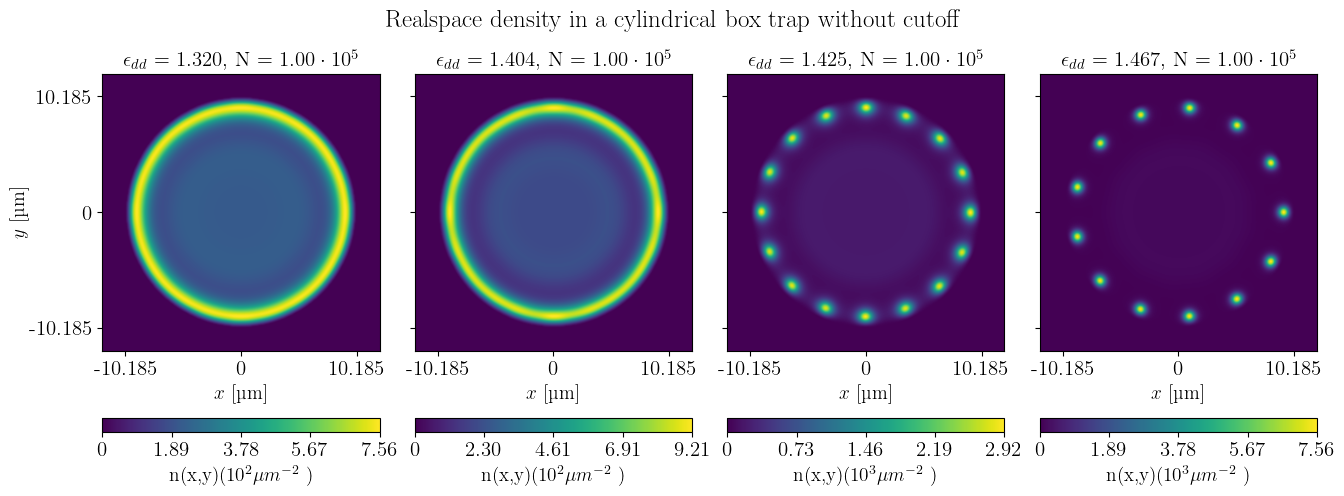

In [9]:
plot_in_a_row(10.185, save = True, vmax_input=None, plot_phase=False)